In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline
sns.set_style("whitegrid")

In [5]:
df=pd.read_excel('Dataset for Data Analytics (1).xlsx', sheet_name='Sheet1')

In [6]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [8]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [9]:
df['Date']=pd.to_datetime(df['Date'])

In [12]:
numeric_cols=['Quantity','UnitPrice','TotalPrice','ItemsInCart']
df[numeric_cols].describe()

,Quantity,UnitPrice,TotalPrice,ItemsInCart
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,1053.968300,5.485000
std,1.407557,197.177146,819.856558,2.281983
min,1.000000,11.390000,11.390000,1.000000
25%,2.000000,186.062500,410.520000,4.000000
50%,3.000000,364.210000,823.615000,5.000000
75%,4.000000,521.570000,1578.475000,7.000000
max,5.000000,699.930000,3456.400000,10.000000


# Checking for outliers using IQR Method

In [13]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['TotalPrice'] < Q1 - 1.5*IQR) | (df['TotalPrice'] > Q3 + 1.5*IQR)]
print(f"Outliers in TotalPrice: {len(outliers)}")
outliers[['OrderID', 'TotalPrice', 'Product', 'Quantity']].head()

Outliers in TotalPrice: 8


,OrderID,TotalPrice,Product,Quantity
107,ORD200107,3353.75,Printer,5
326,ORD200326,3352.40,Laptop,5
328,ORD200328,3370.20,Tablet,5
469,ORD200469,3384.90,Chair,5
632,ORD200632,3390.80,Laptop,5


# Visualizing the distribution

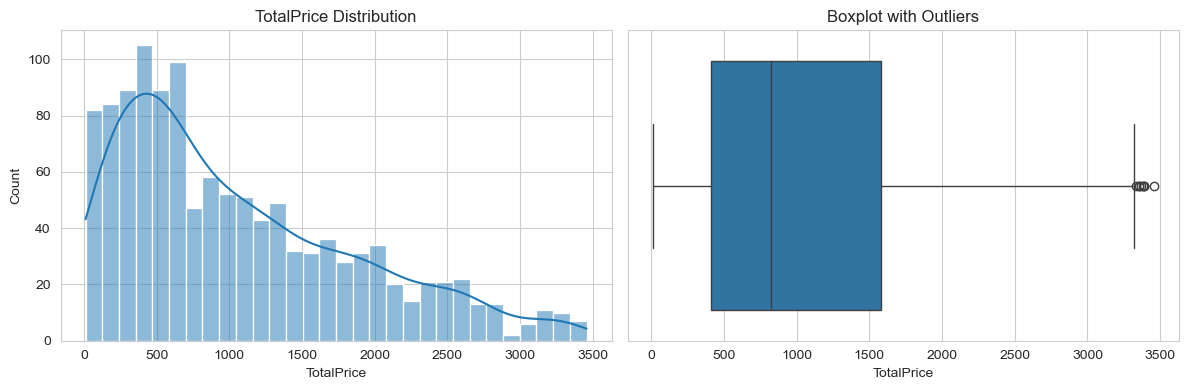

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['TotalPrice'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('TotalPrice Distribution')
sns.boxplot(x=df['TotalPrice'], ax=axes[1])
axes[1].set_title('Boxplot with Outliers')
plt.tight_layout()
plt.show()

# Analyzing trends by product

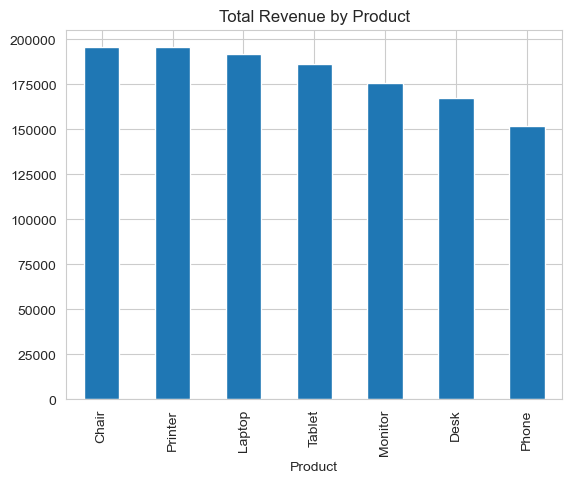

In [15]:
df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Revenue by Product')
plt.show()

# Analyzing trends by order status

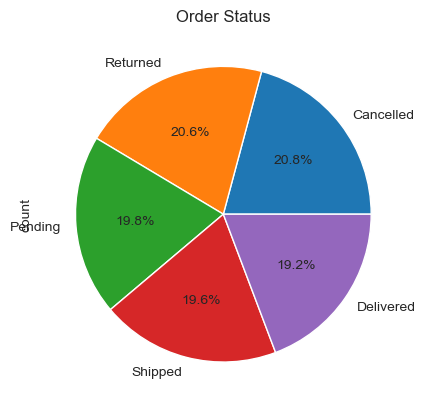

In [16]:
df['OrderStatus'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Order Status')
plt.show()

# Handling null values in coupon c

In [17]:
print(f"Percentage: {df['CouponCode'].isnull().mean()*100:.1f}%")

Percentage: 25.8%


In [19]:
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')
df.groupby('CouponCode')['TotalPrice'].mean().sort_values(ascending=False)

CouponCode
FREESHIP     1070.405719
SAVE10       1065.874196
No Coupon    1043.370259
WINTER15     1035.902534
Name: TotalPrice, dtype: float64

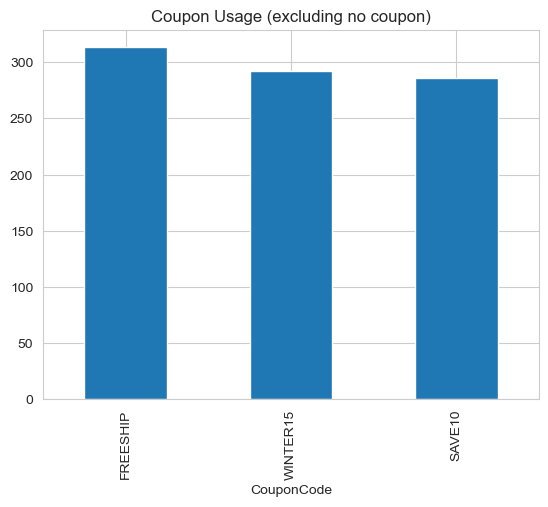

In [20]:
coupon_counts = df[df['CouponCode'] != 'No Coupon']['CouponCode'].value_counts()
coupon_counts.plot(kind='bar')
plt.title('Coupon Usage (excluding no coupon)')
plt.show()

In [21]:
# Compare TotalPrice between null and non-null CouponCode
df.groupby(df['CouponCode'].isna())['TotalPrice'].describe()

,count,mean,std,min,25%,50%,75%,max
CouponCode,,,,,,,,
False,1200.0,1053.9683,819.856558,11.39,410.52,823.615,1578.475,3456.4


In [22]:
df['CouponCode'].value_counts(dropna=False)

CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64

# Compare total price between no couon and actual coupons

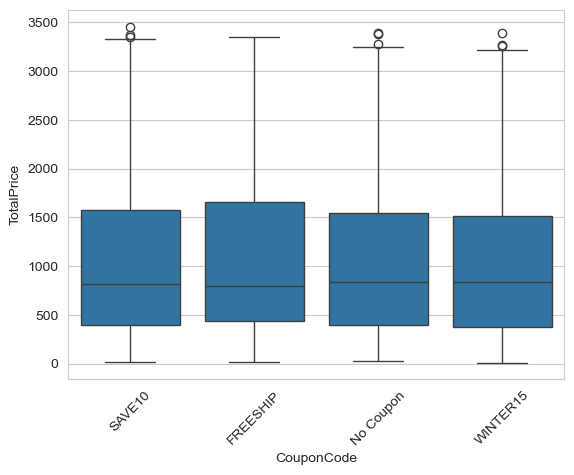

,mean,median,count
CouponCode,,,
FREESHIP,1070.405719,793.400,313
No Coupon,1043.370259,834.120,309
SAVE10,1065.874196,823.065,286
WINTER15,1035.902534,838.710,292


In [23]:
# Boxplot
sns.boxplot(data=df, x='CouponCode', y='TotalPrice')
plt.xticks(rotation=45)
plt.show()

# Grouped statistics
df.groupby('CouponCode')['TotalPrice'].agg(['mean', 'median', 'count'])

# Statistical test(t-test) , are Coupon orders cheaper?

In [24]:
from scipy.stats import ttest_ind
no_coupon = df[df['CouponCode'] == 'No Coupon']['TotalPrice']
with_coupon = df[df['CouponCode'] != 'No Coupon']['TotalPrice']
t_stat, p_value = ttest_ind(no_coupon, with_coupon)
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Significant difference in TotalPrice between coupon and non-coupon orders")
else:
    print("No significant difference")

P-value: 0.7921
No significant difference


# Comparing each coupon type individually

In [25]:
# Compare 'No Coupon' vs each coupon
for coupon in ['SAVE10', 'FREESHIP', 'WINTER15']:
    group = df[df['CouponCode'] == coupon]['TotalPrice']
    t_stat, p = ttest_ind(no_coupon, group)
    print(f"{coupon} vs No Coupon: p={p:.4f}")

SAVE10 vs No Coupon: p=0.7409
FREESHIP vs No Coupon: p=0.6781
WINTER15 vs No Coupon: p=0.9105


# Visualizing distributions side by side

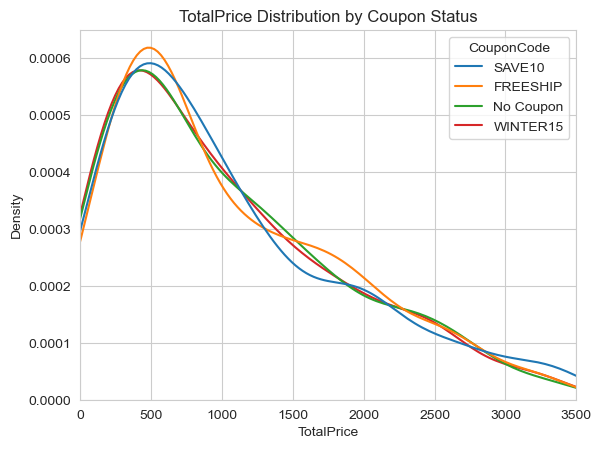

In [26]:
sns.kdeplot(data=df, x='TotalPrice', hue='CouponCode', common_norm=False)
plt.title('TotalPrice Distribution by Coupon Status')
plt.xlim(0, 3500)
plt.show()

In [27]:
# Check average Quantity for FREESHIP vs others
df.groupby('CouponCode')['Quantity'].mean()

CouponCode
FREESHIP     2.920128
No Coupon    3.045307
SAVE10       2.951049
WINTER15     2.863014
Name: Quantity, dtype: float64

# Product Trends

In [28]:
# Total revenue by product
product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
print(product_revenue)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


In [29]:
# Average unit price by product
avg_price = df.groupby('Product')['UnitPrice'].mean().sort_values(ascending=False)
print(avg_price)

Product
Phone      375.217564
Tablet     367.679106
Monitor    358.663620
Laptop     357.707052
Chair      355.660281
Printer    351.714917
Desk       329.608118
Name: UnitPrice, dtype: float64


In [30]:
# Most frequently ordered products
product_freq = df['Product'].value_counts()
print(product_freq)

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64


# Order Status Analysis

In [31]:
# Distribution of order status
status_counts = df['OrderStatus'].value_counts(normalize=True) * 100
print(status_counts)


OrderStatus
Cancelled    20.833333
Returned     20.583333
Pending      19.750000
Shipped      19.583333
Delivered    19.250000
Name: proportion, dtype: float64


In [32]:
# Average total price by status
status_avg_price = df.groupby('OrderStatus')['TotalPrice'].mean().sort_values(ascending=False)
print(status_avg_price)

OrderStatus
Cancelled    1105.584840
Pending      1081.553376
Delivered    1050.217835
Shipped      1047.487574
Returned      984.929960
Name: TotalPrice, dtype: float64


# Payment methods trends

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


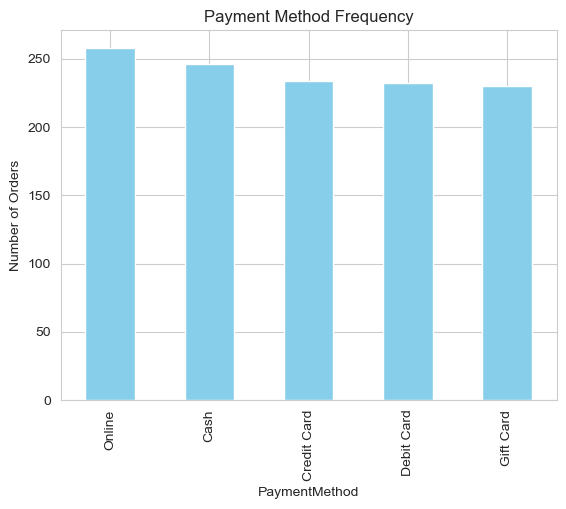

In [33]:
# Payment method popularity
payment_counts = df['PaymentMethod'].value_counts()
print(payment_counts)
payment_counts.plot(kind='bar', color='skyblue')
plt.title('Payment Method Frequency')
plt.ylabel('Number of Orders')
plt.show()

In [34]:
# Average total price by payment method
payment_avg = df.groupby('PaymentMethod')['TotalPrice'].mean().sort_values(ascending=False)
print(payment_avg)

PaymentMethod
Credit Card    1127.553974
Gift Card      1070.973565
Cash           1056.041829
Online         1017.220698
Debit Card     1001.556810
Name: TotalPrice, dtype: float64


# Referral Source trends

In [35]:
# Referral source distribution
ref_counts = df['ReferralSource'].value_counts(normalize=True) * 100
print(ref_counts)

ReferralSource
Instagram    21.583333
Email        20.833333
Google       20.083333
Facebook     19.000000
Referral     18.500000
Name: proportion, dtype: float64


In [36]:
# Revenue by referral source
ref_revenue = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)
print(ref_revenue)

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64


In [37]:
# Average order value by referral source
ref_avg = df.groupby('ReferralSource')['TotalPrice'].mean().sort_values(ascending=False)
print(ref_avg)

ReferralSource
Facebook     1098.293421
Instagram    1062.878185
Email        1047.234200
Google       1039.176266
Referral     1021.691802
Name: TotalPrice, dtype: float64


# Time Series Trends

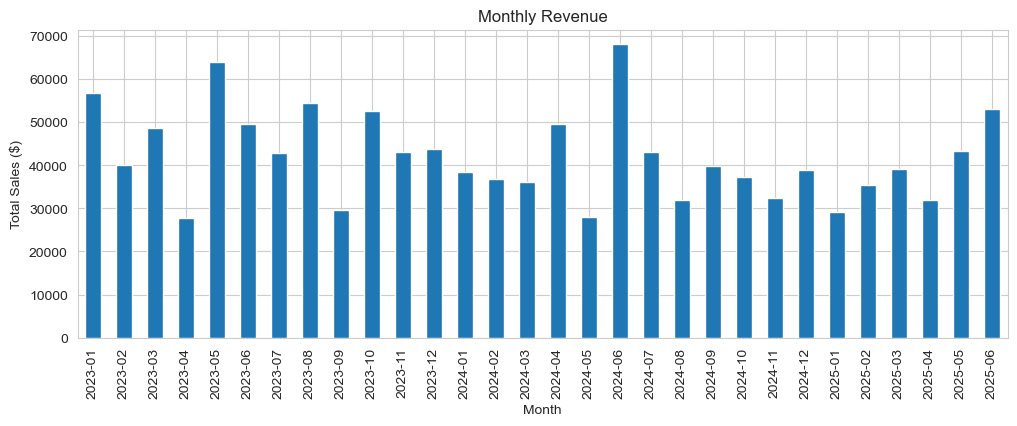

In [38]:
# Convert Date already done
df['Month'] = df['Date'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['TotalPrice'].sum()
monthly_revenue.plot(kind='bar', figsize=(12,4))
plt.title('Monthly Revenue')
plt.ylabel('Total Sales ($)')
plt.show()

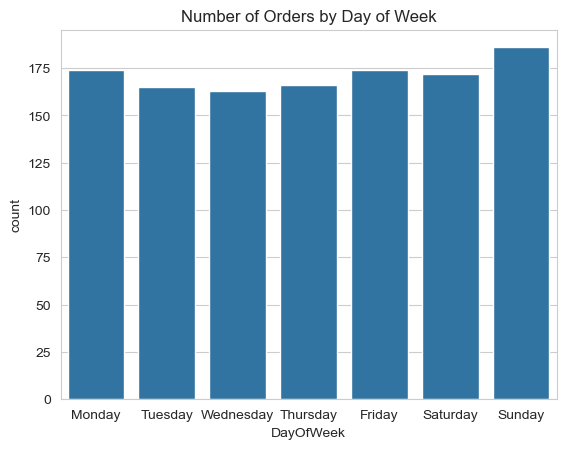

In [39]:
# Orders by day of week
df['DayOfWeek'] = df['Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='DayOfWeek', order=day_order)
plt.title('Number of Orders by Day of Week')
plt.show()

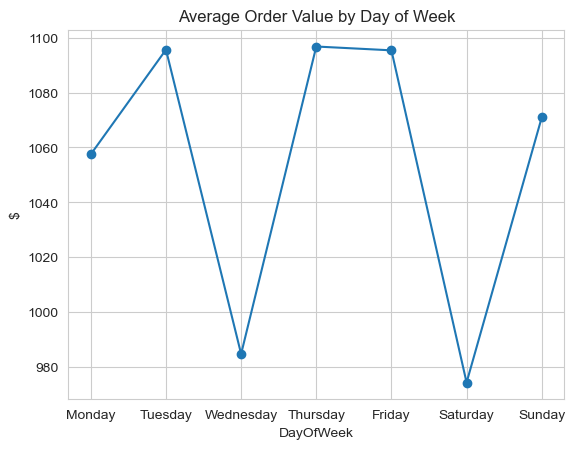

In [40]:
# Average total price by day of week
df.groupby('DayOfWeek')['TotalPrice'].mean().reindex(day_order).plot(kind='line', marker='o')
plt.title('Average Order Value by Day of Week')
plt.ylabel('$')
plt.show()

# Correlation Heatmaps

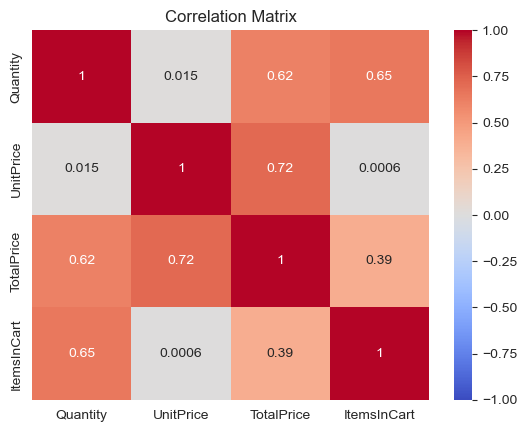

In [41]:
numeric_cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

# Outlier Detection

In [42]:
# Z‑score method on TotalPrice
z_scores = np.abs(stats.zscore(df['TotalPrice']))
outliers_z = df[z_scores > 3]
print(f"Outliers using Z-score (>3): {len(outliers_z)}")
outliers_z[['OrderID', 'TotalPrice', 'Product']].head()

Outliers using Z-score (>3): 0


,OrderID,TotalPrice,Product


In [43]:
# IQR method
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = df[(df['TotalPrice'] < Q1 - 1.5*IQR) | (df['TotalPrice'] > Q3 + 1.5*IQR)]
print(f"Outliers using IQR: {len(outliers_iqr)}")

Outliers using IQR: 8
